# Tree-search optimisation analysis (2026-05-13)

Compare tree-search runtimes and likelihood values across three implementations:

- **baseline_openacc** — current OpenACC baseline (label `baseline` in filenames)
- **t1_clang** — clang_vanila CPU build at t1 step (label `t1_clang`)
- **t1_openacc** — OpenACC build with the t1 optimisation (label `t1_real`)

All runs use 100 taxa, tree 1, run 1. We pull timing and log-likelihood from the IQ-TREE log files for both DNA (GTR+I+G4) and AA (LG+I+G4) datasets at lengths 10k, 100k, and 1M sites.

**Note on completeness:** several long runs (1M sites and AA 100k clang) did not reach `BEST SCORE FOUND` before being terminated. Those rows are flagged `incomplete` and excluded from like-for-like runtime comparisons.

In [1]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

RESULTS_ROOT = Path('/Users/u7826985/Projects/Nvidia/results/2026_05_13_treesearch_opt').resolve()
print('Looking under:', RESULTS_ROOT)

Looking under: /Users/u7826985/Projects/Nvidia/results/2026_05_13_treesearch_opt


## 1. Discover log files and parse them

In [2]:
FILENAME_RE = re.compile(
    r'output_teesearch_(?P<impl>baseline|t1_clang|t1_real)_'
    r'(?P<datatype>DNA|AA)_(?P<model>[^_]+)_'
    r'(?P<compiler>OPENACC|CLANG_VANILA)_taxa(?P<taxa>\d+)_run(?P<run>\d+)_'
    r'tree_(?P<tree>\d+)_(?P<length>\d+)_'
    r'iqtree3.*?\.log$'
)

IMPL_LABEL = {
    'baseline': 'baseline_openacc',
    't1_clang': 't1_clang_vanila',
    't1_real':  't1_openacc',
}

PATTERNS = {
    'total_wall_s':      r'Total wall-clock time used: ([0-9.]+) sec',
    'total_cpu_s':       r'Total CPU time used: ([0-9.]+) sec',
    'tree_search_wall_s':r'Wall-clock time used for tree search: ([0-9.]+) sec',
    'tree_search_cpu_s': r'CPU time used for tree search: ([0-9.]+) sec',
    'best_score':        r'BEST SCORE FOUND\s*:\s*(-?[0-9.]+)',
    'rapidnj_ll':        r'Log-likelihood of RapidNJ tree:\s*(-?[0-9.]+)',
    'compute_initial_s': r'Computing log-likelihood of 98 initial trees \.\.\. ([0-9.]+) seconds',
    'iterations':        r'TREE SEARCH COMPLETED AFTER (\d+) ITERATIONS',
    'init_parsimony_s':  r'Create initial parsimony tree by phylogenetic likelihood library \(PLL\)\.\.\. ([0-9.]+) seconds',
}

def parse_log(path: Path) -> dict:
    text = path.read_text(errors='replace')
    out = {'path': str(path), 'filename': path.name}
    m = FILENAME_RE.match(path.name)
    if m:
        out.update(m.groupdict())
        out['impl_label'] = IMPL_LABEL.get(out['impl'], out['impl'])
        out['length'] = int(out['length'])
    for key, pat in PATTERNS.items():
        match = re.search(pat, text)
        out[key] = float(match.group(1)) if match else np.nan
    out['complete'] = not np.isnan(out['total_wall_s']) and not np.isnan(out['best_score'])
    return out

log_files = sorted(p for p in RESULTS_ROOT.rglob('output_teesearch_*.log'))
print(f'Found {len(log_files)} log files')
for p in log_files:
    print(' -', p.relative_to(RESULTS_ROOT))

Found 18 log files
 - AA/len_10000/output_teesearch_baseline_AA_LG+I+G4_OPENACC_taxa100_run1_tree_1_10000_iqtree3_AA_OPENACC_Poisson_100taxa_10000len_OPENACC_run1_tree_1_10000_aa_iqtree.log
 - AA/len_10000/output_teesearch_t1_clang_AA_LG+I+G4_CLANG_VANILA_taxa100_run1_tree_1_10000_iqtree3_AA_CLANG_VANILA_Poisson_100taxa_10000len_CLANG_VANILA_run1_tree_1_10000_aa_iqtree.log
 - AA/len_10000/output_teesearch_t1_real_AA_LG+I+G4_OPENACC_taxa100_run1_tree_1_10000_iqtree3_AA_OPENACC_Poisson_100taxa_10000len_OPENACC_run1_tree_1_10000_aa_iqtree.log
 - AA/len_100000/output_teesearch_baseline_AA_LG+I+G4_OPENACC_taxa100_run1_tree_1_100000_iqtree3_AA_OPENACC_Poisson_100taxa_100000len_OPENACC_run1_tree_1_100000_aa_iqtree.log
 - AA/len_100000/output_teesearch_t1_clang_AA_LG+I+G4_CLANG_VANILA_taxa100_run1_tree_1_100000_iqtree3_AA_CLANG_VANILA_Poisson_100taxa_100000len_CLANG_VANILA_run1_tree_1_100000_aa_iqtree.log
 - AA/len_100000/output_teesearch_t1_real_AA_LG+I+G4_OPENACC_taxa100_run1_tree_1_100000_i

In [3]:
records = [parse_log(p) for p in log_files]
df = pd.DataFrame(records)
df = df[[
    'datatype', 'length', 'impl_label',
    'total_wall_s', 'total_cpu_s',
    'tree_search_wall_s', 'tree_search_cpu_s',
    'compute_initial_s', 'init_parsimony_s',
    'iterations', 'best_score', 'rapidnj_ll', 'complete', 'filename', 'path',
]].sort_values(['datatype', 'length', 'impl_label']).reset_index(drop=True)
df.drop(columns=['path'])  # display without the long path column

,datatype,length,impl_label,total_wall_s,total_cpu_s,tree_search_wall_s,tree_search_cpu_s,compute_initial_s,init_parsimony_s,iterations,best_score,rapidnj_ll,complete,filename
0,AA,10000,baseline_openacc,276.782,276.690,275.172,275.096,12.088,0.216,102.000,"-966,826.511","-976,147.934",True,output_teesearch_baseline_AA_LG+I+G4_OPENACC_t...
1,AA,10000,t1_clang_vanila,873.796,872.990,867.630,866.966,49.964,0.249,102.000,"-966,826.511","-976,147.934",True,output_teesearch_t1_clang_AA_LG+I+G4_CLANG_VAN...
2,AA,10000,t1_openacc,280.013,280.012,278.435,278.458,12.254,0.217,102.000,"-966,826.511","-976,147.934",True,output_teesearch_t1_real_AA_LG+I+G4_OPENACC_ta...
3,AA,100000,baseline_openacc,"1,268.936","1,261.716","1,258.826","1,251.786",45.467,3.198,102.000,"-9,027,400.981","-9,117,687.271",True,output_teesearch_baseline_AA_LG+I+G4_OPENACC_t...
4,AA,100000,t1_clang_vanila,NaN,NaN,NaN,NaN,636.096,3.899,NaN,NaN,"-9,117,687.271",False,output_teesearch_t1_clang_AA_LG+I+G4_CLANG_VAN...
5,AA,100000,t1_openacc,"1,245.703","1,239.185","1,236.044","1,229.679",44.466,3.129,102.000,"-9,027,400.981","-9,117,687.271",True,output_teesearch_t1_real_AA_LG+I+G4_OPENACC_ta...
6,AA,1000000,baseline_openacc,NaN,NaN,NaN,NaN,NaN,107.934,NaN,NaN,"-94,789,915.140",False,output_teesearch_baseline_AA_LG+I+G4_OPENACC_t...
7,AA,1000000,t1_clang_vanila,NaN,NaN,NaN,NaN,NaN,133.628,NaN,NaN,"-94,789,915.140",False,output_teesearch_t1_clang_AA_LG+I+G4_CLANG_VAN...
8,AA,1000000,t1_openacc,NaN,NaN,NaN,NaN,279.822,104.926,NaN,NaN,"-94,789,915.140",False,output_teesearch_t1_real_AA_LG+I+G4_OPENACC_ta...
9,DNA,10000,baseline_openacc,194.010,194.006,192.905,192.911,8.345,0.062,102.000,"-616,191.885","-625,572.750",True,output_teesearch_baseline_DNA_GTR+I+G4_OPENACC...


## 2. Runtime comparison

Pivot wall-clock time (seconds) by datatype, length, and implementation. `NaN` means the run did not finish — see Section 4 for the partial progress those runs reached.

In [4]:
wall_pivot = df.pivot_table(
    index=['datatype', 'length'],
    columns='impl_label',
    values='total_wall_s',
    aggfunc='first',
)[['baseline_openacc', 't1_clang_vanila', 't1_openacc']]
wall_pivot

impl_label        baseline_openacc  t1_clang_vanila  t1_openacc
datatype length                                                
AA       10000             276.782          873.796     280.013
         100000          1,268.936              NaN   1,245.703
DNA      10000             194.010          136.505     190.225
         100000            308.077        1,437.136     316.209
         1000000         1,961.672              NaN   1,995.934

In [5]:
ts_pivot = df.pivot_table(
    index=['datatype', 'length'],
    columns='impl_label',
    values='tree_search_wall_s',
    aggfunc='first',
)[['baseline_openacc', 't1_clang_vanila', 't1_openacc']]
ts_pivot

impl_label        baseline_openacc  t1_clang_vanila  t1_openacc
datatype length                                                
AA       10000             275.172          867.630     278.435
         100000          1,258.826              NaN   1,236.044
DNA      10000             192.905          135.278     189.140
         100000            304.304        1,422.182     312.283
         1000000         1,922.086              NaN   1,954.668

### Speed-ups

Ratios > 1 mean the optimisation is faster than the reference.

- `t1_openacc_vs_baseline`: t1 OpenACC speed-up over the OpenACC baseline (this is the optimisation we're trying to land).
- `t1_openacc_vs_clang`: how much t1 OpenACC beats the clang_vanila CPU build (proxy for GPU-vs-CPU benefit).
- `baseline_vs_clang`: how the existing baseline already compares to the CPU build.

In [6]:
speedup = pd.DataFrame(index=wall_pivot.index)
speedup['baseline_openacc_s']  = wall_pivot['baseline_openacc']
speedup['t1_clang_vanila_s']   = wall_pivot['t1_clang_vanila']
speedup['t1_openacc_s']        = wall_pivot['t1_openacc']
speedup['t1_openacc_vs_baseline'] = wall_pivot['baseline_openacc'] / wall_pivot['t1_openacc']
speedup['t1_openacc_vs_clang']    = wall_pivot['t1_clang_vanila'] / wall_pivot['t1_openacc']
speedup['baseline_vs_clang']      = wall_pivot['t1_clang_vanila'] / wall_pivot['baseline_openacc']
speedup

baseline_openacc_s  t1_clang_vanila_s  t1_openacc_s  \
datatype length                                                         
AA       10000               276.782            873.796       280.013   
         100000            1,268.936                NaN     1,245.703   
DNA      10000               194.010            136.505       190.225   
         100000              308.077          1,437.136       316.209   
         1000000           1,961.672                NaN     1,995.934   

                  t1_openacc_vs_baseline  t1_openacc_vs_clang  \
datatype length                                                 
AA       10000                     0.988                3.121   
         100000                    1.019                  NaN   
DNA      10000                     1.020                0.718   
         100000                    0.974                4.545   
         1000000                   0.983                  NaN   

                  baseline_vs_clang  
datatype length                      
AA       10000                3.157  
         100000                 NaN  
DNA      10000                0.704  
         100000               4.665  
         1000000                NaN

## 3. Cross-verify likelihoods

All three implementations should converge to the same `BEST SCORE FOUND` log-likelihood, because the optimisation must not change numerical correctness. We tabulate the values per (datatype, length) and show the max pairwise absolute difference. A non-zero difference signals a numerical regression.

In [7]:
ll_pivot = df.pivot_table(
    index=['datatype', 'length'],
    columns='impl_label',
    values='best_score',
    aggfunc='first',
)[['baseline_openacc', 't1_clang_vanila', 't1_openacc']]
ll_pivot

impl_label        baseline_openacc  t1_clang_vanila      t1_openacc
datatype length                                                    
AA       10000        -966,826.511     -966,826.511    -966,826.511
         100000     -9,027,400.981              NaN  -9,027,400.981
DNA      10000        -616,191.885     -616,191.885    -616,191.885
         100000     -6,102,417.191   -6,102,417.191  -6,102,417.191
         1000000   -63,520,168.764              NaN -63,520,168.764

In [8]:
def row_max_abs_diff(row):
    vals = row.dropna().values
    if len(vals) < 2:
        return np.nan
    return float(np.max(vals) - np.min(vals))

ll_check = ll_pivot.copy()
ll_check['max_abs_diff'] = ll_check.apply(row_max_abs_diff, axis=1)
ll_check['match'] = ll_check['max_abs_diff'].apply(lambda v: 'OK' if (np.isnan(v) or v == 0.0) else 'MISMATCH')
ll_check

impl_label        baseline_openacc  t1_clang_vanila      t1_openacc  \
datatype length                                                       
AA       10000        -966,826.511     -966,826.511    -966,826.511   
         100000     -9,027,400.981              NaN  -9,027,400.981   
DNA      10000        -616,191.885     -616,191.885    -616,191.885   
         100000     -6,102,417.191   -6,102,417.191  -6,102,417.191   
         1000000   -63,520,168.764              NaN -63,520,168.764   

impl_label        max_abs_diff match  
datatype length                       
AA       10000           0.000    OK  
         100000          0.000    OK  
DNA      10000           0.000    OK  
         100000          0.000    OK  
         1000000         0.000    OK

Also cross-check the RapidNJ initial-tree log-likelihood. This is identical input across the three runs (same alignment), so it provides a sanity check that the likelihood kernel agrees at step 0.

In [9]:
rnj_pivot = df.pivot_table(
    index=['datatype', 'length'],
    columns='impl_label',
    values='rapidnj_ll',
    aggfunc='first',
)[['baseline_openacc', 't1_clang_vanila', 't1_openacc']]
rnj_check = rnj_pivot.copy()
rnj_check['max_abs_diff'] = rnj_pivot.apply(row_max_abs_diff, axis=1)
rnj_check

impl_label        baseline_openacc  t1_clang_vanila      t1_openacc  \
datatype length                                                       
AA       10000        -976,147.934     -976,147.934    -976,147.934   
         100000     -9,117,687.271   -9,117,687.271  -9,117,687.271   
         1000000   -94,789,915.140  -94,789,915.140 -94,789,915.140   
DNA      10000        -625,572.750     -625,572.750    -625,572.750   
         100000     -6,148,148.225   -6,148,148.225  -6,148,148.225   
         1000000   -64,142,474.627  -64,142,474.627 -64,142,474.627   

impl_label        max_abs_diff  
datatype length                 
AA       10000           0.000  
         100000          0.000  
         1000000         0.000  
DNA      10000           0.000  
         100000          0.000  
         1000000         0.000

## 4. Incomplete runs

These runs did not reach `BEST SCORE FOUND`. We show the final iteration / time recorded in the log so you can see how far they got.

In [10]:
ITER_RE = re.compile(r'^Iteration (\d+) / LogL: (-?[0-9.]+) / Time: ([0-9hms:]+)', re.MULTILINE)

def last_iteration(path: Path):
    text = path.read_text(errors='replace')
    matches = list(ITER_RE.finditer(text))
    if not matches:
        return (np.nan, np.nan, '')
    m = matches[-1]
    return (int(m.group(1)), float(m.group(2)), m.group(3))

incomplete = df[~df['complete']].copy()
if incomplete.empty:
    print('All runs completed.')
    incomplete_view = None
else:
    last_iters = [last_iteration(Path(p)) for p in incomplete['path']]
    incomplete[['last_iter', 'last_logL', 'last_time']] = last_iters
    incomplete_view = incomplete[['datatype', 'length', 'impl_label',
                                  'last_iter', 'last_logL', 'last_time']].reset_index(drop=True)
incomplete_view

,datatype,length,impl_label,last_iter,last_logL,last_time
0,AA,100000,t1_clang_vanila,70.000,"-9,027,401.129",2h:0m:55s
1,AA,1000000,baseline_openacc,NaN,NaN,
2,AA,1000000,t1_clang_vanila,NaN,NaN,
3,AA,1000000,t1_openacc,40.000,"-94,093,302.070",3h:15m:41s
4,DNA,1000000,t1_clang_vanila,10.000,"-63,520,300.001",1h:22m:41s


## 5. Plots

Wall-clock runtime per implementation, faceted by datatype and length (log scale). Incomplete runs are shown as hatched bars with their final recorded time so the comparison is honest about which runs ran to completion.

Every figure is also written to `figures/*.png` next to the notebook.

Saved figures/total_wall_clock.png


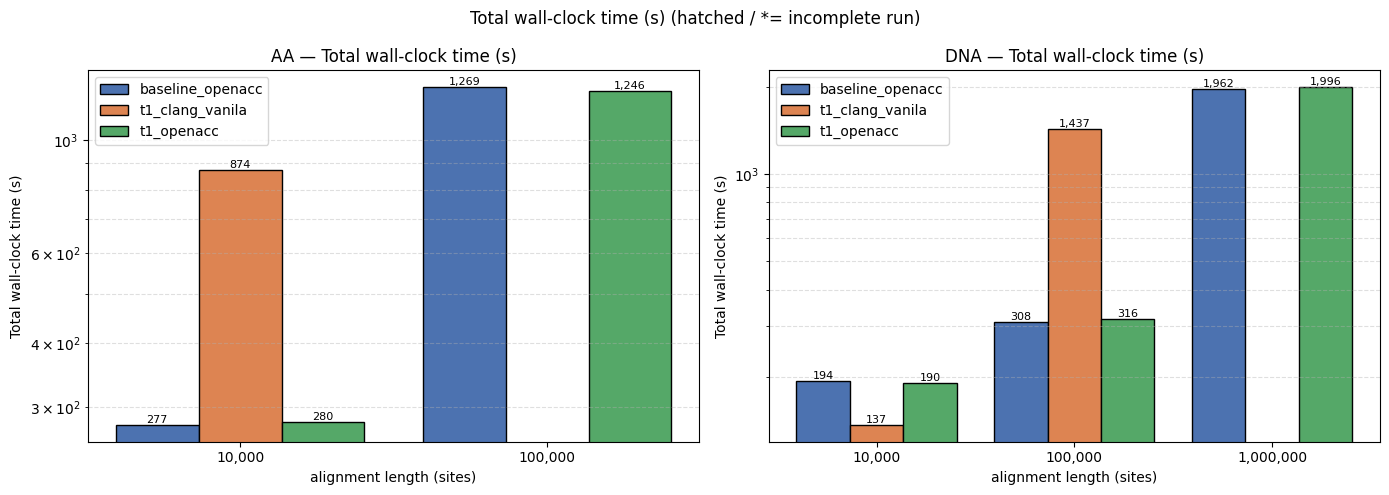

In [11]:
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

def plot_runtime(metric='total_wall_s', title='Total wall-clock time (s)', savename=None):
    pivot = df.pivot_table(
        index=['datatype', 'length'],
        columns='impl_label',
        values=metric,
        aggfunc='first',
    )[['baseline_openacc', 't1_clang_vanila', 't1_openacc']]
    complete_pivot = df.pivot_table(
        index=['datatype', 'length'],
        columns='impl_label',
        values='complete',
        aggfunc='first',
    )[['baseline_openacc', 't1_clang_vanila', 't1_openacc']]
    datatypes = sorted({i[0] for i in pivot.index})
    fig, axes = plt.subplots(1, len(datatypes), figsize=(7 * len(datatypes), 5), sharey=False)
    if len(datatypes) == 1:
        axes = [axes]
    for ax, dt in zip(axes, datatypes):
        sub = pivot.xs(dt, level='datatype')
        sub_complete = complete_pivot.xs(dt, level='datatype')
        lengths = sub.index.tolist()
        impls = ['baseline_openacc', 't1_clang_vanila', 't1_openacc']
        x = np.arange(len(lengths))
        width = 0.27
        colors = {'baseline_openacc': '#4c72b0', 't1_clang_vanila': '#dd8452', 't1_openacc': '#55a868'}
        for j, impl in enumerate(impls):
            vals = sub[impl].values
            done = sub_complete[impl].values
            bars = ax.bar(x + (j - 1) * width, vals, width, label=impl, color=colors[impl],
                          edgecolor='black')
            for bar, d in zip(bars, done):
                if not bool(d):
                    bar.set_hatch('//')
            for xi, v, d in zip(x + (j - 1) * width, vals, done):
                if not np.isnan(v):
                    ax.text(xi, v, f'{v:,.0f}{"*" if not bool(d) else ""}', ha='center', va='bottom', fontsize=8, rotation=0)
        ax.set_xticks(x)
        ax.set_xticklabels([f'{L:,}' for L in lengths])
        ax.set_xlabel('alignment length (sites)')
        ax.set_ylabel(title)
        ax.set_title(f'{dt} — {title}')
        ax.set_yscale('log')
        ax.grid(True, which='both', axis='y', linestyle='--', alpha=0.4)
        ax.legend()
    plt.suptitle(title + ' (hatched / *= incomplete run)')
    plt.tight_layout()
    if savename:
        out = FIG_DIR / savename
        fig.savefig(out, dpi=150, bbox_inches='tight')
        print(f'Saved {out}')
    return fig

plot_runtime('total_wall_s', 'Total wall-clock time (s)', savename='total_wall_clock.png')
plt.show()

Saved figures/tree_search_wall_clock.png


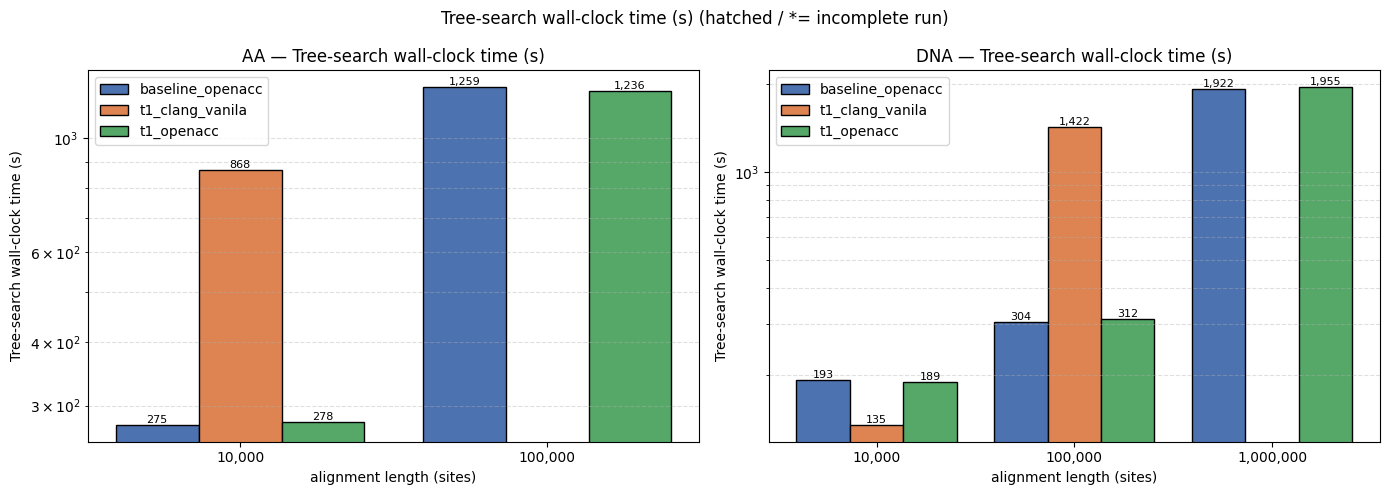

In [12]:
plot_runtime('tree_search_wall_s', 'Tree-search wall-clock time (s)', savename='tree_search_wall_clock.png')
plt.show()

### Speed-up plot

How much faster is `t1_openacc` than the OpenACC baseline and the clang CPU build? Bars > 1.0 mean the optimisation wins.

Saved figures/speedup.png


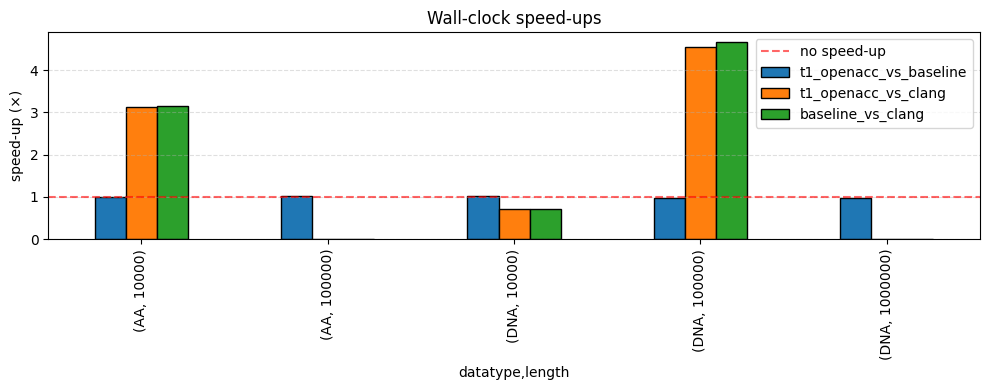

In [13]:
su = speedup[['t1_openacc_vs_baseline', 't1_openacc_vs_clang', 'baseline_vs_clang']].copy()
su = su.dropna(how='all')
ax = su.plot(kind='bar', figsize=(10, 4), edgecolor='black')
ax.axhline(1.0, color='red', linestyle='--', alpha=0.6, label='no speed-up')
ax.set_ylabel('speed-up (×)')
ax.set_title('Wall-clock speed-ups')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
speedup_path = FIG_DIR / 'speedup.png'
ax.get_figure().savefig(speedup_path, dpi=150, bbox_inches='tight')
print(f'Saved {speedup_path}')
plt.show()

## 6. Summary

Generate a single tidy table to drop into the writeup.

In [14]:
summary = wall_pivot.copy()
summary.columns = [f'{c}_wall_s' for c in summary.columns]
summary = summary.join(ll_check[['baseline_openacc', 't1_clang_vanila', 't1_openacc', 'max_abs_diff', 'match']].rename(
    columns={c: f'{c}_logL' for c in ['baseline_openacc', 't1_clang_vanila', 't1_openacc']}
))
summary['t1_openacc_vs_baseline'] = speedup['t1_openacc_vs_baseline']
summary['t1_openacc_vs_clang']    = speedup['t1_openacc_vs_clang']
summary

baseline_openacc_wall_s  t1_clang_vanila_wall_s  \
datatype length                                                     
AA       10000                    276.782                 873.796   
         100000                 1,268.936                     NaN   
DNA      10000                    194.010                 136.505   
         100000                   308.077               1,437.136   
         1000000                1,961.672                     NaN   

                  t1_openacc_wall_s  baseline_openacc_logL  \
datatype length                                              
AA       10000              280.013           -966,826.511   
         100000           1,245.703         -9,027,400.981   
DNA      10000              190.225           -616,191.885   
         100000             316.209         -6,102,417.191   
         1000000          1,995.934        -63,520,168.764   

                  t1_clang_vanila_logL  t1_openacc_logL  max_abs_diff match  \
datatype length                                                               
AA       10000            -966,826.511     -966,826.511         0.000    OK   
         100000                    NaN   -9,027,400.981         0.000    OK   
DNA      10000            -616,191.885     -616,191.885         0.000    OK   
         100000         -6,102,417.191   -6,102,417.191         0.000    OK   
         1000000                   NaN  -63,520,168.764         0.000    OK   

                  t1_openacc_vs_baseline  t1_openacc_vs_clang  
datatype length                                                
AA       10000                     0.988                3.121  
         100000                    1.019                  NaN  
DNA      10000                     1.020                0.718  
         100000                    0.974                4.545  
         1000000                   0.983                  NaN

In [15]:
summary.to_csv('treesearch_opt_summary.csv')
df.to_csv('treesearch_opt_all_runs.csv', index=False)
print('Wrote treesearch_opt_summary.csv and treesearch_opt_all_runs.csv')

Wrote treesearch_opt_summary.csv and treesearch_opt_all_runs.csv
